In [47]:
# Sentiment-Driven Crypto Trader Analysis

### Author: Shree Ganga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Plot settings
plt.style.use('ggplot')

print("Libraries loaded successfully!")

D:\Anaconda\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Libraries loaded successfully!


In [2]:
fear_greed = pd.read_csv(
    r"E:\Shree\sentiment-driven-crypto-trader-analysis\data\fear_greed_index.csv"
)

trades = pd.read_csv(
    r"E:\Shree\sentiment-driven-crypto-trader-analysis\data\historical_data.csv"
)

print("Fear & Greed Shape:", fear_greed.shape)
print("Trades Shape:", trades.shape)

Fear & Greed Shape: (2644, 4)
Trades Shape: (211224, 16)


In [3]:
print("Fear & Greed Columns:")
print(fear_greed.columns.tolist())

print("\nTrades Columns:")
print(trades.columns.tolist())

Fear & Greed Columns:
['timestamp', 'value', 'classification', 'date']

Trades Columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [4]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
# Missing Values & Duplicates
print("===== FEAR & GREED =====")
print("\nMissing Values:")
print(fear_greed.isnull().sum())

print("\nDuplicates:")
print(fear_greed.duplicated().sum())

print("\n===== TRADES =====")
print("\nMissing Values:")
print(trades.isnull().sum())

print("\nDuplicates:")
print(trades.duplicated().sum())

===== FEAR & GREED =====

Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates:
0

===== TRADES =====

Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates:
0


In [8]:
# Convert Dates
fear_greed['date'] = pd.to_datetime(fear_greed['date'])

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

In [9]:
print(fear_greed['date'].head())
print(trades['date'].head())

0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[ns]
0   2024-12-02
1   2024-12-02
2   2024-12-02
3   2024-12-02
4   2024-12-02
Name: date, dtype: datetime64[ns]


In [15]:
# Merge Datasets
df = trades.merge(
    fear_greed[['date', 'classification', 'value']],
    on='date',
    how='left'
)

print(df.shape)
df.head()

(211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [13]:
print(df['classification'].isnull().sum())

6


In [16]:
# cleaning rest 6 rows
df = df.dropna(subset=['classification'])

print(df.shape)

(211218, 19)


In [18]:
# Feature Engineering & Metrics

# Win/Loss Indicator
df['Win'] = (df['Closed PnL'] > 0).astype(int)

# Daily PnL per Trader
daily_pnl = (
    df.groupby(['Account', 'date'])['Closed PnL']
      .sum()
      .reset_index()
)

# Trades Per Day
trades_per_day = (
    df.groupby('date')
      .size()
      .reset_index(name='trade_count')
)

# Average Trade Size
avg_trade_size = (
    df.groupby('Account')['Size USD']
      .mean()
      .reset_index(name='avg_trade_size')
)

# Long/Short Distribution
long_short_ratio = (
    df['Side']
      .value_counts(normalize=True)
      * 100
)

print("Feature Engineering Completed Successfully!")

Feature Engineering Completed Successfully!


In [19]:
# Average PnL by Sentiment

sentiment_pnl = (
    df.groupby('classification')['Closed PnL']
      .mean()
      .sort_values(ascending=False)
)

sentiment_pnl

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64

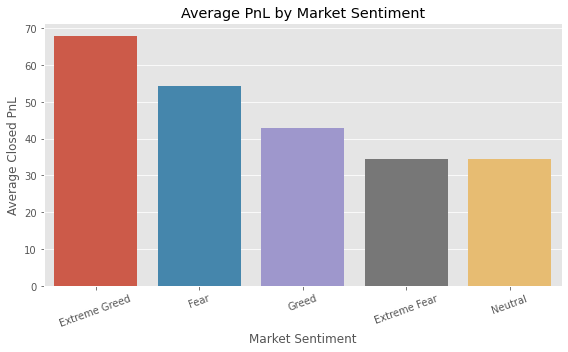

In [58]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=sentiment_pnl.index,
    y=sentiment_pnl.values
)

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.savefig(
    r'E:\Shree\sentiment-driven-crypto-trader-analysis\charts\average_pnl_by_sentiment.png',
    bbox_inches='tight'
)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [27]:
win_rate_sentiment = (
    df.groupby('classification')['Win']
      .mean()
      .sort_values(ascending=False)
      * 100
)

win_rate_sentiment

classification
Extreme Greed    46.494299
Fear             42.076750
Neutral          39.699093
Greed            38.482794
Extreme Fear     37.060748
Name: Win, dtype: float64

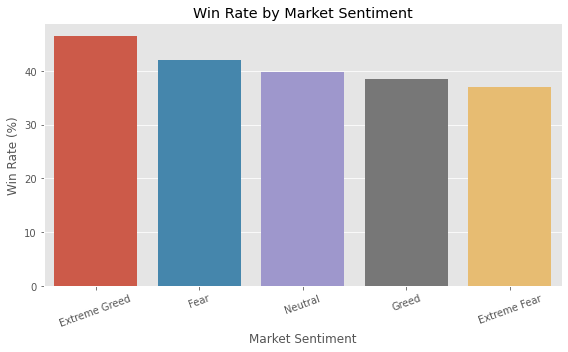

In [57]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=win_rate_sentiment.index,
    y=win_rate_sentiment.values
)

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    r'E:\Shree\sentiment-driven-crypto-trader-analysis\charts\win_rate_by_sentiment.png',
    bbox_inches='tight'
)

plt.show()

In [25]:
print(df.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'classification', 'value', 'Win']


In [30]:
# Fear vs Greed Comparison

fear_greed_compare = (
    df[df['classification'].isin(['Fear', 'Greed'])]
    .groupby('classification')
    .agg({
        'Closed PnL': 'mean',
        'Win': 'mean',
        'Size USD': 'mean'
    })
)

fear_greed_compare['Win'] = fear_greed_compare['Win'] * 100

fear_greed_compare.rename(columns={
    'Closed PnL': 'Average PnL',
    'Win': 'Win Rate (%)',
    'Size USD': 'Average Trade Size'
}, inplace=True)

fear_greed_compare

,Average PnL,Win Rate (%),Average Trade Size
classification,,,
Fear,54.290400,42.076750,7816.109931
Greed,42.743559,38.482794,5736.884375


In [31]:
# Trading Activity by Sentiment

activity = (
    df.groupby('classification')
      .size()
      .reset_index(name='Number_of_Trades')
      .sort_values('Number_of_Trades', ascending=False)
)

activity

,classification,Number_of_Trades
2,Fear,61837
3,Greed,50303
1,Extreme Greed,39992
4,Neutral,37686
0,Extreme Fear,21400


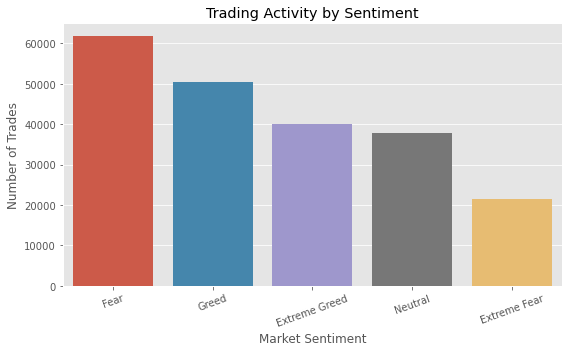

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=activity,
    x='classification',
    y='Number_of_Trades'
)

plt.title("Trading Activity by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    r'E:\Shree\sentiment-driven-crypto-trader-analysis\charts\trading_activity_by_sentiment.png',
    bbox_inches='tight'
)

plt.show()

In [33]:
# Frequent vs Infrequent Traders

trader_frequency = (
    df.groupby('Account')
      .size()
      .reset_index(name='Trade_Count')
)

median_trades = trader_frequency['Trade_Count'].median()

trader_frequency['Segment'] = np.where(
    trader_frequency['Trade_Count'] >= median_trades,
    'Frequent Trader',
    'Infrequent Trader'
)

trader_frequency.head()

,Account,Trade_Count,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent Trader


In [36]:
segment_analysis = (
    trader_frequency.merge(
        df.groupby('Account')['Closed PnL']
          .mean()
          .reset_index(),
        on='Account'
    )
)

segment_analysis.groupby('Segment')['Closed PnL'].mean()

Segment
Frequent Trader       57.577434
Infrequent Trader    136.005260
Name: Closed PnL, dtype: float64

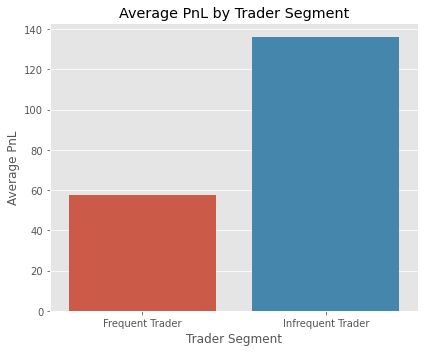

In [37]:
segment_pnl = (
    segment_analysis.groupby('Segment')['Closed PnL']
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,5))

sns.barplot(
    data=segment_pnl,
    x='Segment',
    y='Closed PnL'
)

plt.title("Average PnL by Trader Segment")
plt.xlabel("Trader Segment")
plt.ylabel("Average PnL")

plt.tight_layout()

plt.savefig(
    r'E:\Shree\sentiment-driven-crypto-trader-analysis\charts\trader_segment_pnl.png',
    bbox_inches='tight'
)

plt.show()

In [38]:
# Consistent Winners Analysis

trader_winrate = (
    df.groupby('Account')['Win']
      .mean()
      .reset_index()
)

trader_winrate['Win_Rate'] = trader_winrate['Win'] * 100

trader_winrate['Segment'] = np.where(
    trader_winrate['Win_Rate'] >= 50,
    'Consistent Winner',
    'Other Trader'
)

trader_winrate.head()

,Account,Win,Win_Rate,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,35.961236,Other Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,44.271978,Other Trader
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,30.191651,Other Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,43.858463,Other Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,51.991355,Consistent Winner


In [39]:
winner_analysis = (
    trader_winrate.merge(
        df.groupby('Account')['Closed PnL']
          .mean()
          .reset_index(),
        on='Account'
    )
)

winner_analysis.groupby('Segment')['Closed PnL'].mean()

Segment
Consistent Winner    88.360793
Other Trader         97.663474
Name: Closed PnL, dtype: float64

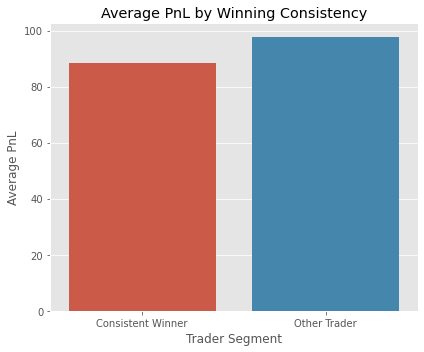

In [40]:
winner_chart = (
    winner_analysis.groupby('Segment')['Closed PnL']
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,5))

sns.barplot(
    data=winner_chart,
    x='Segment',
    y='Closed PnL'
)

plt.title("Average PnL by Winning Consistency")
plt.xlabel("Trader Segment")
plt.ylabel("Average PnL")

plt.tight_layout()

plt.savefig(
    r'E:\Shree\sentiment-driven-crypto-trader-analysis\charts\consistent_winners.png',
    bbox_inches='tight'
)

plt.show()

In [44]:
# Long vs Short Distribution

long_short = (
    df['Side']
    .value_counts(normalize=True)
    * 100
)

long_short

Side
SELL    51.381984
BUY     48.618016
Name: proportion, dtype: float64

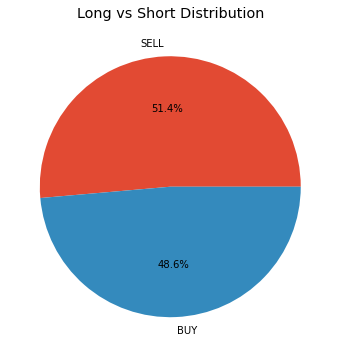

In [46]:
plt.figure(figsize=(6,6))

plt.pie(
    long_short.values,
    labels=long_short.index,
    autopct='%1.1f%%'
)

plt.title("Long vs Short Distribution")

plt.savefig(
    r'E:\Shree\sentiment-driven-crypto-trader-analysis\charts\long_short_distribution.png',
    bbox_inches='tight'
)

plt.show()

In [50]:
trader_frequency = (
    df.groupby('Account')
      .size()
      .reset_index(name='Trade_Count')
)

median_trades = trader_frequency['Trade_Count'].median()

trader_frequency['Segment'] = np.where(
    trader_frequency['Trade_Count'] >= median_trades,
    'Frequent Trader',
    'Infrequent Trader'
)

trader_frequency.head()

,Account,Trade_Count,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent Trader


In [51]:
segment_analysis = trader_frequency.merge(
    df.groupby('Account')['Closed PnL']
      .mean()
      .reset_index(),
    on='Account'
)

segment_pnl = (
    segment_analysis.groupby('Segment')['Closed PnL']
    .mean()
    .reset_index()
)

segment_pnl

,Segment,Closed PnL
0,Frequent Trader,57.577434
1,Infrequent Trader,136.005260


In [52]:
trader_winrate = (
    df.groupby('Account')['Win']
      .mean()
      .reset_index()
)

trader_winrate['Win_Rate'] = trader_winrate['Win'] * 100

trader_winrate['Segment'] = np.where(
    trader_winrate['Win_Rate'] >= 50,
    'Consistent Winner',
    'Other Trader'
)

trader_winrate.head()

,Account,Win,Win_Rate,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612,35.961236,Other Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720,44.271978,Other Trader
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917,30.191651,Other Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585,43.858463,Other Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914,51.991355,Consistent Winner


In [53]:
winner_analysis = trader_winrate.merge(
    df.groupby('Account')['Closed PnL']
      .mean()
      .reset_index(),
    on='Account'
)

winner_chart = (
    winner_analysis.groupby('Segment')['Closed PnL']
    .mean()
    .reset_index()
)

winner_chart

,Segment,Closed PnL
0,Consistent Winner,88.360793
1,Other Trader,97.663474


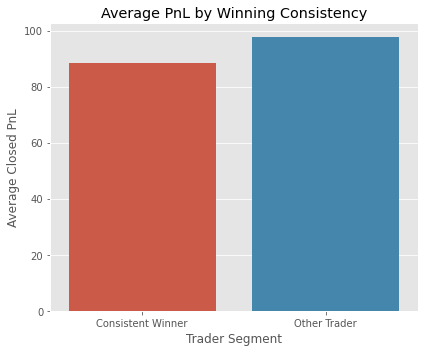

In [54]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=winner_chart,
    x='Segment',
    y='Closed PnL'
)

plt.title("Average PnL by Winning Consistency")
plt.xlabel("Trader Segment")
plt.ylabel("Average Closed PnL")

plt.tight_layout()

plt.savefig(
    r'E:\Shree\sentiment-driven-crypto-trader-analysis\charts\consistent_winners.png',
    bbox_inches='tight'
)

plt.show()

In [55]:
long_short = (
    df['Side']
    .value_counts(normalize=True)
    * 100
)

print(long_short)

Side
SELL    51.381984
BUY     48.618016
Name: proportion, dtype: float64


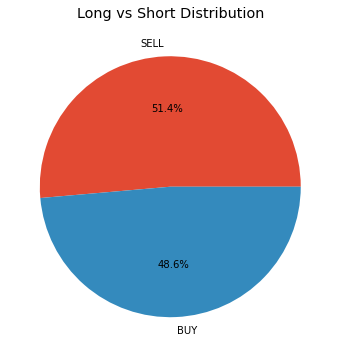

In [56]:
plt.figure(figsize=(6,6))

plt.pie(
    long_short.values,
    labels=long_short.index,
    autopct='%1.1f%%'
)

plt.title("Long vs Short Distribution")

plt.savefig(
    r'E:\Shree\sentiment-driven-crypto-trader-analysis\charts\long_short_distribution.png',
    bbox_inches='tight'
)

plt.show()